In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re


# 1 part

In [78]:
df = pd.read_csv('../data/_data.csv', encoding='utf-8')

In [79]:
df = df.drop(columns=['Unnamed: 0'])
df = df.reset_index(drop=True)

In [80]:
df.columns=['Ad_ID', 'Number_of_rooms', 'Type', 'Metro', 'Address',
 'Area_m2', 'Building', 'Parking', 'Price', 'Phones', 'Description',
 'Renovation', 'Room_area_m2', 'Balcony', 'Windows', 'Bathroom',
 'Children/pets_allowed', 'Additional', 'Residential_complex_name',
 'Building_series', 'Ceiling_height_m', 'Elevator', 'Garbage_chute',
 'Ad_link']

ya_i_columns = ['Ad_ID', 'Description', 'Renovation', 'Room_area_m2', 'Balcony', 'Windows', 'Bathroom', 'Children/pets_allowed']

In [81]:
# Обработать колонки:
# Description	
# (+) Renovation	
# (+) Room_area_m2	
# (+) Balcony	
# (+) Windows	
# (+) Bathroom	
# (+) Children/pets_allowed
# Очистить от NaN
# Добавить Dummy-кодирование 

def extract_numbers(text):
    if pd.isna(text):
        return []
    numbers_str = re.findall(r'\d+(?:[.,]\d+)?', str(text))
    return [float(x.replace(',', '.')) for x in numbers_str]

def sum_func(text):
    if pd.isna(text):
        return 0
    numbers = re.findall(r'\((\d+)\)', text)
    return sum(int(num) for num in numbers)

ya_i_df = df[ya_i_columns]

ya_i_df['Renovation'] = ya_i_df['Renovation']

ya_i_df['Room_area_m2'] = ya_i_df['Room_area_m2'].apply(extract_numbers)

ya_i_df['Balcony_count'] = ya_i_df['Balcony'].apply(sum_func)
ya_i_df['Balcony'] = ya_i_df['Balcony'].str.replace(r'\s*\(\d+\)', '', regex=True)

ya_i_df['Bathroom_count'] = ya_i_df['Bathroom'].apply(sum_func)
ya_i_df['Bathroom'] = ya_i_df['Bathroom'].str.replace(r'\s*\(\d+\)', '', regex=True)

ya_i_df['Description']

ya_i_df['Bathroom_count'].unique()


array([0, 3, 2, 1, 4, 6, 5])

In [82]:
df['Renovation'] = df['Renovation']

df['Room_area_m2'] = df['Room_area_m2'].apply(extract_numbers)

df['Balcony_count'] = df['Balcony'].apply(sum_func)
df['Balcony'] = df['Balcony'].str.replace(r'\s*\(\d+\)', '', regex=True)

df['Bathroom_count'] = df['Bathroom'].apply(sum_func)
df['Bathroom'] = df['Bathroom'].str.replace(r'\s*\(\d+\)', '', regex=True)

df['Bathroom_count']

0        0
1        3
2        3
3        3
4        2
        ..
23363    1
23364    1
23365    1
23366    2
23367    1
Name: Bathroom_count, Length: 23368, dtype: int64

# 2 part

In [83]:
df = pd.read_csv('../data/data_v0_1.csv')
df = df.drop(columns=['Unnamed: 0'])
df = df.reset_index(drop=True)
df.columns

Index(['Ad_ID', 'Type', 'Metro', 'Address', 'Parking', 'Price', 'Phones',
       'Description', 'Renovation', 'Room_area_m2', 'Balcony', 'Windows',
       'Bathroom', 'Children/pets_allowed', 'Additional', 'Ceiling_height_m',
       'Ad_link', 'Balcony_count', 'Bathroom_count', 'Number_of_rooms_int',
       'Type of room', 'extra_money', 'Full_area', 'Rooms_area', 'Float_floor',
       'Height_building', 'Building_type', 'Garbage_chute(yes)',
       'Garbage_chute(no)', 'pass_elev', 'cargo_elev', 'elevator_more_2'],
      dtype='str')

# Графики зависимостей

In [ ]:
ya_i_list = ['Renovation',
'Room_area_m2',
'Balcony',
'Balcony_count',
'Bathroom',
'Bathroom_count']

other_list = ['Price', 'Type', 'Full_area', 'Float_floor', 'Height_building', 'Garbage_chute(yes)']

df['Balcony_count'].unique()

array([0, 1, 3, 5, 2, 6, 4, 8])

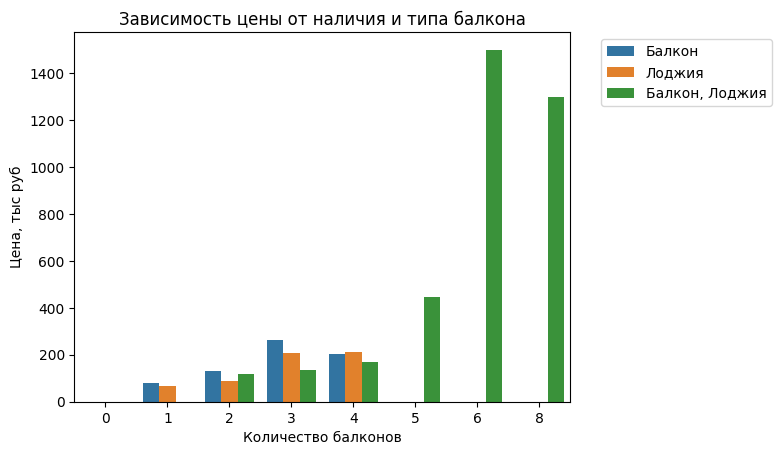

<Figure size 768x576 with 0 Axes>

In [120]:
ax = sns.barplot(
    data=df,
    x='Balcony_count',
    y=df['Price']/1000,
    hue='Balcony',
    errorbar=None
)

ax.set(
    title='Зависимость цены от наличия и типа балкона',
    xlabel='Количество балконов',
    ylabel='Цена, тыс руб'
    )

ax.legend(
    bbox_to_anchor=(1.42, 1),
    loc="upper right"
)

plt.figure(dpi=120)

plt.show()

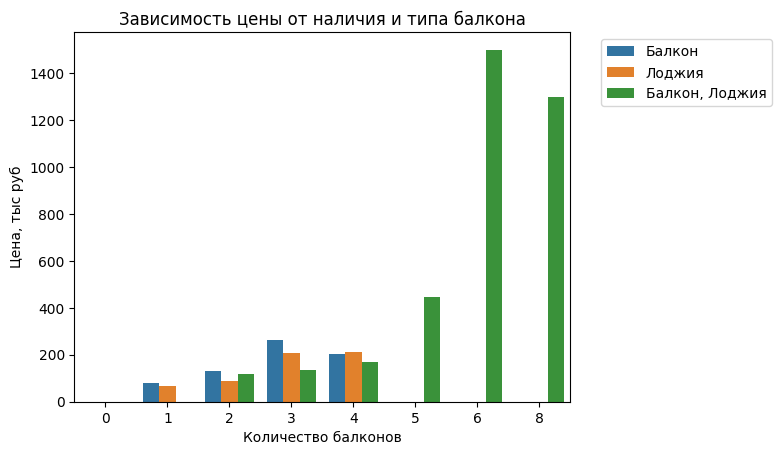

<Figure size 768x576 with 0 Axes>

In [ ]:
ax = sns.barplot(
    data=df,
    x='Float_floor',
    y=df['Price']/1000,
    hue='Balcony',
    errorbar=None
)

ax.set(
    title='Зависимость цены от наличия и типа балкона',
    xlabel='Количество балконов',
    ylabel='Цена, тыс руб'
    )

ax.legend(
    bbox_to_anchor=(1.42, 1),
    loc="upper right"
)

plt.figure(dpi=120)

plt.show()

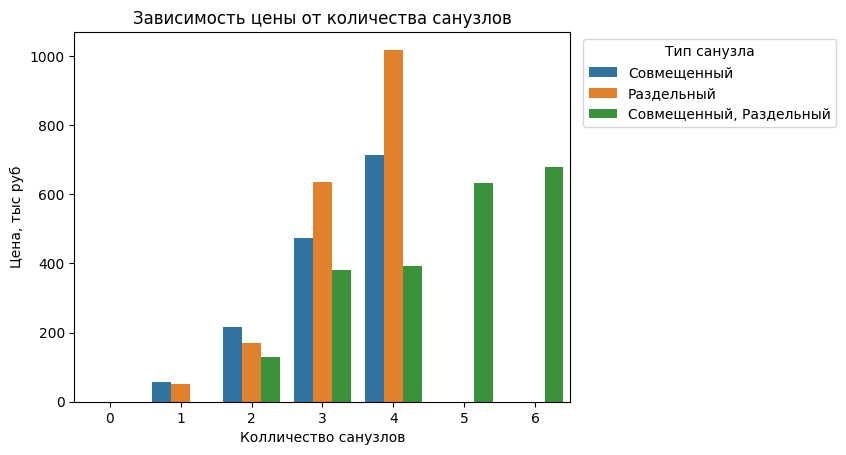

<Figure size 768x576 with 0 Axes>

In [ ]:
ax = sns.barplot(
    data=df,
    x='Bathroom_count',
    y=df['Price']/1000,
    hue='Bathroom',
    errorbar=None
)

ax.set(
    title='Зависимость цены от количества и типа санузлов',
    xlabel='Колличество санузлов',
    ylabel='Цена, тыс руб',
    )

ax.legend(
    title='Тип санузла',
    bbox_to_anchor=(1.55, 1),
    loc="upper right"
)

plt.figure(dpi=120)

plt.show()

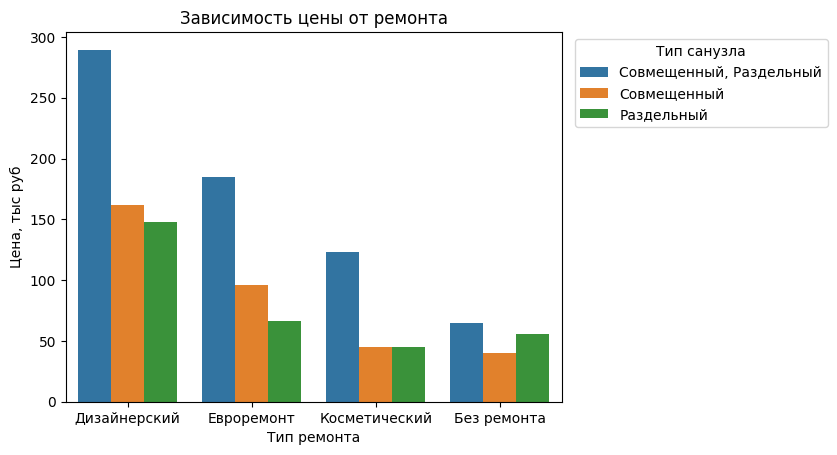

<Figure size 768x576 with 0 Axes>

In [ ]:
ax = sns.barplot(
    data=df,
    x='Renovation',
    y=df['Price']/1000,
    hue='Bathroom',
    errorbar=None
)

ax.set(
    title='Зависимость цены от ремонта и типа санузла',
    xlabel='Тип ремонта',
    ylabel='Цена, тыс руб',
    )

ax.legend(
    title='Тип санузла',
    bbox_to_anchor=(1.55, 1),
    loc="upper right"
)

plt.figure(dpi=120)

plt.show()